# Bag of Words Exploration Notebook

## 1. Setup 

In [1]:
import os
import re
import glob
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from stop_words import stop_word_list

# Directory containing .txt files
TEXT_DIR = "data/text"

# Directory containing other metadata
DATA_DIR = "data"

## 2. Load documents 

In [2]:
filepaths = glob.glob(os.path.join(TEXT_DIR, "*.txt"))

corpus = []
filenames = []

for fp in filepaths:
    with open(fp, 'r', encoding='utf-8', errors='ignore') as f:
        corpus.append(f.read())
        filenames.append(os.path.basename(fp))

print(f"Loaded {len(corpus)} documents")

Loaded 762 documents


In [3]:
#nltk.download('punkt_tab')

stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep only letters
    tokens = word_tokenize(text)
    stems = [stemmer.stem(t) for t in tokens]
    return " ".join(stems)

corpus_stemmed = [preprocess(doc) for doc in corpus]

## 3. Create Bag-of-Words representation 

In [4]:
# https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

vectorizer = CountVectorizer(
    strip_accents='unicode',
    stop_words=stop_word_list,
    max_df=1.0,
    min_df=5
)

X = vectorizer.fit_transform(corpus_stemmed)

print("Matrix shape:", X.shape)

/opt/anaconda3/envs/islp/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['articl', 'mon'] not in stop_words.
  warnings.warn(


Matrix shape: (762, 14347)


## 4. Convert to DataFrame for exploration 

In [5]:
feature_names = vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(X.toarray(), columns=feature_names, index=filenames)

bow_df.head()

,aa,aaron,aback,abalon,abandon,abash,abat,abattoir,abbey,abbi,...,zigzag,zillion,zinc,zip,zipper,zombi,zone,zoo,zoom,zu
412 Brisk Money.txt,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
164 Specimen 313.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
270 When We Were Heroes.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
720 Tie A Yellow Ribbon.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
176 Apologue.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## 5. Most common words overall 

In [6]:
word_counts = bow_df.sum(axis=0).sort_values(ascending=False)

print("Top 20 words:")
print(word_counts.head(40))

Top 20 words:
thi        20002
time       11949
hand       10565
eye         8610
onli        7971
befor       7969
thing       7897
head        7344
turn        6906
someth      6621
man         6513
face        6386
long        6190
day         6181
peopl       6051
thought     5993
littl       5951
tri         5921
work        5673
ha          5568
good        5273
door        5220
ani         5112
becaus      5081
open        4917
year        4902
whi         4643
feel        4547
room        4494
knew        4329
left        4291
night       4264
place       4253
anoth       4169
voic        4166
arm         3955
walk        3943
live        3937
watch       3921
noth        3887
dtype: int64


## 6. Most important words per document 

In [7]:
def top_words_per_doc(df, n=10):
    results = {}
    for doc in df.index:
        top_words = df.loc[doc].sort_values(ascending=False).head(n)
        results[doc] = top_words[top_words > 0]
    return results

per_doc = top_words_per_doc(bow_df)

# Example: show one document
example_doc = list(per_doc.keys())[0]
print(f"\nTop words in {example_doc}:")
print(per_doc[example_doc])


Top words in 412 Brisk Money.txt:
ada     88
man     45
tape    40
car     39
gun     35
door    35
hand    34
thi     33
mayb    32
hour    32
Name: 412 Brisk Money.txt, dtype: int64


## 7. Document similarity (cosine similarity) 

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(similarity_matrix, index=filenames, columns=filenames)

sim_df.head()

,412 Brisk Money.txt,164 Specimen 313.txt,270 When We Were Heroes.txt,720 Tie A Yellow Ribbon.txt,176 Apologue.txt,616 Dark Warm Heart.txt,186 Tortured.txt,107 River of Souls.txt,659 Grace's Family.txt,006 The Things That Make Me Weak and Strange Get Engineered Away.txt,...,131 Our Candidate.txt,378 Noma Girl.txt,568 The Night Cyclist.txt,221 At the Foot of the Lighthouse (Todai Moto Kurashi).txt,555 Once More Into the Abyss.txt,589 The Thing About Growing up in Jokertown.txt,"525 Tom, Thom.txt",108 Intersections and Interlopers.txt,825 The Sisters of Saint Nicola of The Almost Perpetual Motion vs the Lurch.txt,629 Waiting on a Bright Moon.txt
412 Brisk Money.txt,1.000000,0.224455,0.505447,0.377001,0.159454,0.362564,0.279308,0.379192,0.335487,0.484307,...,0.332497,0.445251,0.382470,0.398971,0.364902,0.443553,0.209519,0.262439,0.238681,0.388901
164 Specimen 313.txt,0.224455,1.000000,0.284029,0.214095,0.094045,0.220521,0.204368,0.223144,0.234989,0.251812,...,0.221925,0.209485,0.244450,0.249369,0.243470,0.262829,0.145135,0.171974,0.183616,0.243469
270 When We Were Heroes.txt,0.505447,0.284029,1.000000,0.465158,0.185648,0.380268,0.333700,0.430726,0.430852,0.524793,...,0.390349,0.472960,0.472066,0.466218,0.448627,0.574788,0.289579,0.355380,0.299361,0.463906
720 Tie A Yellow Ribbon.txt,0.377001,0.214095,0.465158,1.000000,0.161694,0.290417,0.262249,0.378039,0.346078,0.427995,...,0.445198,0.361096,0.337207,0.372826,0.391696,0.401968,0.223470,0.293213,0.265444,0.349154
176 Apologue.txt,0.159454,0.094045,0.185648,0.161694,1.000000,0.120605,0.116098,0.179615,0.144183,0.186585,...,0.163368,0.145249,0.176511,0.152848,0.157076,0.190050,0.096500,0.105739,0.119234,0.184579


## 8. Find most similar documents 

In [9]:
def most_similar(df, doc_name, top_n=5):
    sims = df.loc[doc_name].drop(doc_name)
    return sims.sort_values(ascending=False).head(top_n)

print(f"\nDocuments most similar to {example_doc}:")
print(most_similar(sim_df, example_doc))


Documents most similar to 412 Brisk Money.txt:
300 The Button Man and the Murder Tree.txt    0.540102
642 Bitter Grounds.txt                        0.526204
099 Bitter Grounds.txt                        0.526190
534 Discards.txt                              0.518169
148 The Rook.txt                              0.517205
Name: 412 Brisk Money.txt, dtype: float64


## 9. Optional: visualize top words 

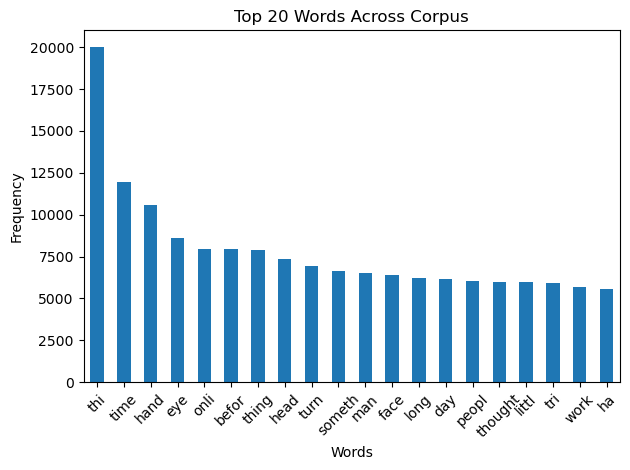

In [10]:
import matplotlib.pyplot as plt

word_counts.head(20).plot(kind='bar')
plt.title("Top 20 Words Across Corpus")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Save outputs 

In [11]:
bow_df.to_csv("outputs/bow_matrix.csv")
sim_df.to_csv("outputs/document_similarity.csv")

print("Saved outputs: bow_matrix.csv, document_similarity.csv")

Saved outputs: bow_matrix.csv, document_similarity.csv


# Sanity Checks

### 1. Locate document pairs with highest similarity.

In [12]:
# Grab just the upper triangle (excluding diagonal).
# This eliminates documents trivial pairs (like documents being similar to themselves)
upper_tri = np.triu(np.ones(sim_df.shape), k=1).astype(bool)

filtered = sim_df.where(upper_tri)

In [13]:
# We'll pull the most similar 5 pairs

top_pairs = (
    filtered.stack()
    .sort_values(ascending=False)
    .head(5)
)
top_pairs

857 The City Born Great.txt                569 The City Born Great.txt                                                                 1.0
308 Burning Girls.txt                      854 Burning Girls.txt                                                                       1.0
621 Caligo Lane.txt                        588 Caligo Lane.txt                                                                         1.0
371 The Tallest Doll in New York City.txt  648 A Valentine from Maria Dahvana Headley- Read "The Tallest Doll in New York City".txt    1.0
714 Read Alex Irvine's "Black Friday".txt  662 Black Friday.txt                                                                        1.0
dtype: float64

In [14]:
duplicates_99 = []

threshold = 0.99  # adjust (0.9–0.99 depending on strictness)

n = similarity_matrix.shape[0]

for i in range(n):
    for j in range(i+1, n):
        if similarity_matrix[i, j] > threshold:
            duplicates_99.append((filenames[i], filenames[j], similarity_matrix[i, j]))

print("Near-duplicate pairs:")
for d in duplicates_99:
    print(d)

Near-duplicate pairs:
('855 The Devil in America.txt', '381 The Devil in America.txt', np.float64(0.9999820643891905))
('371 The Tallest Doll in New York City.txt', '648 A Valentine from Maria Dahvana Headley- Read "The Tallest Doll in New York City".txt', np.float64(1.0000000000000089))
('149 Six Months, Three Days.txt', '858 Six Months Three Days.txt', np.float64(0.9999999999999818))
('621 Caligo Lane.txt', '588 Caligo Lane.txt', np.float64(1.0000000000000122))
('122 Sweetheart.txt', '669 Read Abbey Mei Otis\' "Sweetheart".txt', np.float64(0.9999999999999984))
('857 The City Born Great.txt', '569 The City Born Great.txt', np.float64(1.00000000000002))
('345 The Legend of Sleepy Hollow.txt', '641 The Legend of Sleepy Hollow.txt', np.float64(0.9999006585518637))
('308 Burning Girls.txt', '854 Burning Girls.txt', np.float64(1.0000000000000124))
('099 Bitter Grounds.txt', '642 Bitter Grounds.txt', np.float64(0.9999615909056123))
('714 Read Alex Irvine\'s "Black Friday".txt', '662 Black F

In [15]:
duplicates_75 = []

threshold = 0.75  # adjust (0.9–0.99 depending on strictness)

n = similarity_matrix.shape[0]

for i in range(n):
    for j in range(i+1, n):
        if 0.99 > similarity_matrix[i, j] > threshold:
            duplicates_75.append((filenames[i], filenames[j], similarity_matrix[i, j]))

print("Near-duplicate pairs:")
for d in duplicates_75:
    print(d)

Near-duplicate pairs:
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '770 Judge Dee and the Limits of the Law.txt', np.float64(0.7838687616253689))
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '814 Seven Vampires.txt', np.float64(0.766379642316667))
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '779 Judge Dee and the Three Deaths of Count WErdenfels.txt', np.float64(0.7828012494604134))
('838 Judge Dee and the Mystery of the Missing Manuscript.txt', '868 The Locked Coffin.txt', np.float64(0.7676689220535272))
('790 Easy Job.txt', '840 Time Marked and Mended.txt', np.float64(0.7902439059643305))
('239 The Fire Gown.txt', '234 The Mongolian Wizard.txt', np.float64(0.7553356914628063))
('770 Judge Dee and the Limits of the Law.txt', '814 Seven Vampires.txt', np.float64(0.8331715416158268))
('770 Judge Dee and the Limits of the Law.txt', '779 Judge Dee and the Three Deaths of Count WErdenfels.txt', np.float64(0.8861202790727335))
('770 

In [22]:
%pip install nltk
%pip install krovetzstemmer

Note: you may need to restart the kernel to use updated packages.
  Using cached krovetzstemmer-0.8-cp313-cp313-macosx_10_13_universal2.whl
Note: you may need to restart the kernel to use updated packages.


In [23]:
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer
from krovetzstemmer import Stemmer as KrovetzStemmer
from unpack_documents import CustomPorterStemmer

porter = PorterStemmer()
lancaster = LancasterStemmer()
snowball = SnowballStemmer("english")
porter = PorterStemmer()
custom = CustomPorterStemmer() 
krovetz = KrovetzStemmer()

test_words = ["his", "hers", "herself", "himself", "they", "them", "their",
              "running", "galaxies", "published", "fiction", "she", "he"]

print(f"{'Word':<15} {'Porter':<15} {'Custom':<15} {'Krovetz':<15}")
print("-" * 60)
for w in test_words:
    print(f"{w:<15} {porter.stem(w):<15} {custom.stem(w):<15} {krovetz.stem(w):<15}")

Word            Porter          Custom          Krovetz        
------------------------------------------------------------
his             hi              him             his            
hers            her             her             hers           
herself         herself         her             herself        
himself         himself         him             himself        
they            they            they            they           
them            them            them            them           
their           their           their           their          
running         run             run             running        
galaxies        galaxi          galaxi          galaxy         
published       publish         publish         publish        
fiction         fiction         fiction         fiction        
she             she             she             she            
he              he              he              he             
